## Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

In [2]:
df = pd.read_csv("../data/cleaned/employee_attrition_cleaned.csv")
df.sample(5, random_state=42)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,4,Male,...,3,4,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,4,Female,...,3,3,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,4,Male,...,3,3,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,2,Male,...,3,3,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,4,Male,...,3,4,0,16,3,4,13,11,3,7


## Univariate Analysis

### Business Question

What is the overall employee attrition rate?

In [3]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [4]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

### Observation

Out of 1,470 employees, 237 left the company while 1,233 remained.



### Business Insight

The overall attrition rate is approximately 16%, indicating that roughly one out of every six employees left the organization during the observed period.

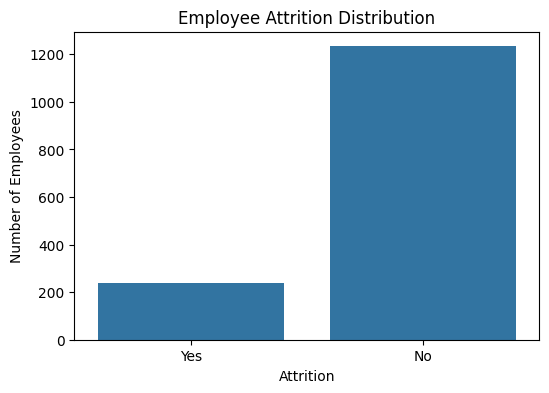

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

### Observation

- The majority of employees remained with the company.
- A smaller proportion of employees left the organization.

## Business Question
What is the age distribution of employees?

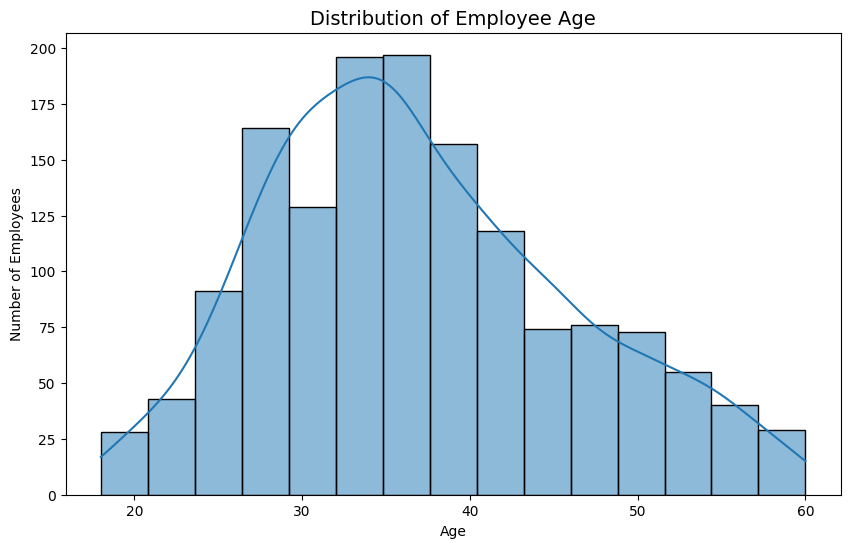

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)
plt.title("Distribution of Employee Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

### Observation

- Employee ages range from **18 to 60 years**.
- Most employees fall between **30 and 40 years** of age.
- The distribution appears approximately bell-shaped with no unusual spikes or gaps.

### Business Insight

The workforce is primarily composed of employees in their early and mid-career stages.

## Business Question
How is monthly income distributed among employees?

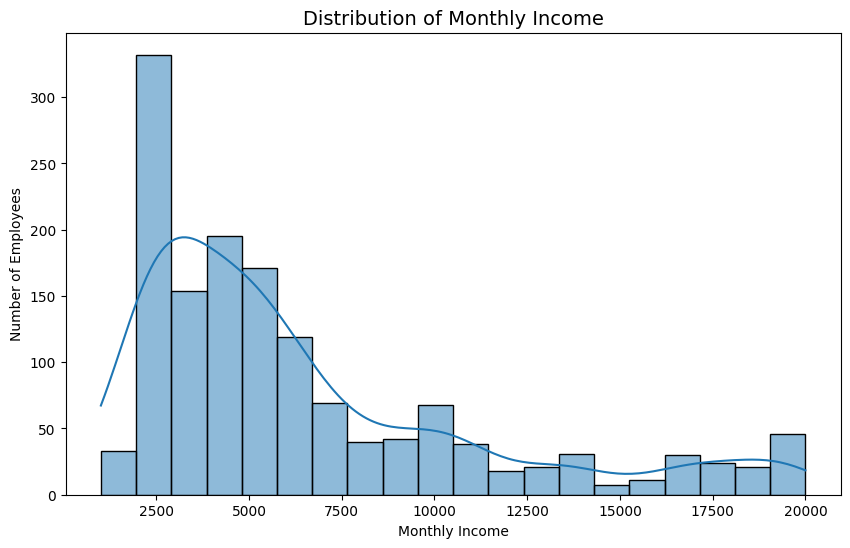

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=20,
    kde=True
)
plt.title("Distribution of Monthly Income",fontsize=14)
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.show()

### Observation

- Monthly income ranges from approximately **1,000 to 20,000**.
- Most employees earn salaries in the lower to middle income range.
- Majority of the employees earn **2500**.

### Business Insight

The organization has a larger proportion of employees in the lower and middle salary brackets, while high-income employees represent a smaller segment of the workforce. This suggests that compensation may be an important factor to investigate further when analyzing employee attrition.

## Observation
How are employees distributed across different departments?

In [9]:
df["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

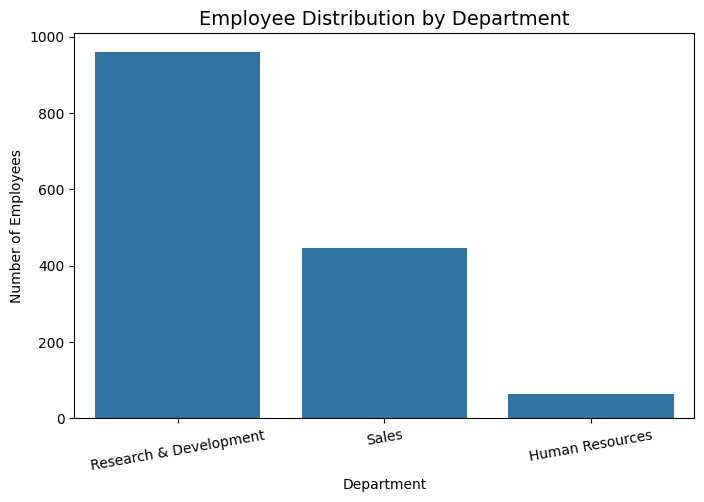

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Department",
    order=df["Department"].value_counts().index
)
plt.title("Employee Distribution by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=10)

plt.show()

### Observation

- Research & Development has the largest workforce.
- Sales is the second-largest department.
- Human Resources has the fewest employees.

### Business Insight

The workforce is unevenly distributed across departments, with Research & Development employing the largest number of employees. This distribution should be considered when analyzing attrition, as departments with more employees may naturally record a higher number of resignations. Therefore, attrition **rates** rather than absolute counts will provide a more meaningful comparison.

## Business Question
How are employees distributed across different job roles?

In [12]:
df["JobRole"].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

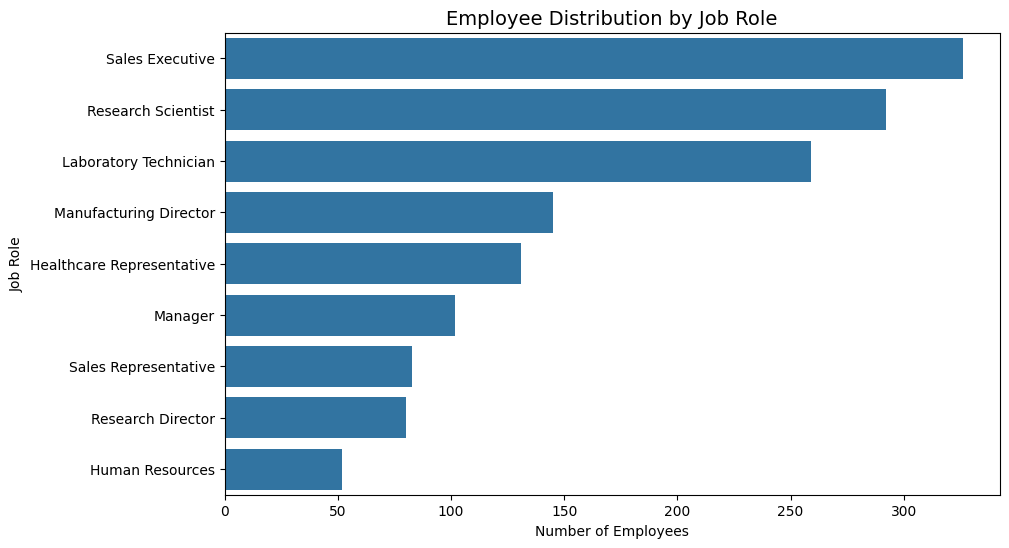

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y="JobRole",
    order=df["JobRole"].value_counts().index
)
plt.title("Employee Distribution by Job Role", fontsize=14)
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.show()

### Observation

- Sales Executive is the most common job role.
- Research Scientist and Laboratory Technician also represent a large portion of the workforce.
- Manager and Human Resources have comparatively fewer employees.

### Business Insight

The organization has a diverse workforce spread across multiple job roles, with Sales Executives forming the largest employee group. 

## Business Question 
How frequently do employees travel for business?

In [14]:
df["BusinessTravel"].value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

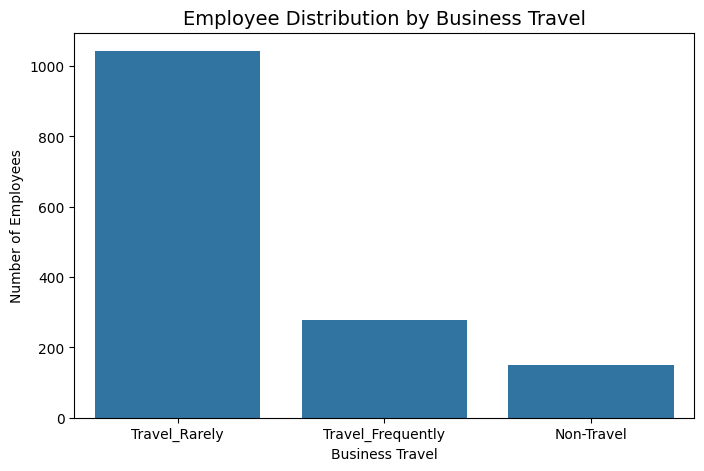

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="BusinessTravel",
    order=df["BusinessTravel"].value_counts().index
)
plt.title("Employee Distribution by Business Travel", fontsize=14)
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")

plt.show()

### Observation

- Most employees travel **rarely** for business.
- A smaller proportion of employees travel **frequently**.
- The least number of employees do **not travel** for business.

### Business Insight

The majority of employees travel only occasionally for work. 

## Business Question
How satisfied are employees with their jobs?

In [17]:
df["JobSatisfaction"].value_counts().sort_index()

JobSatisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64

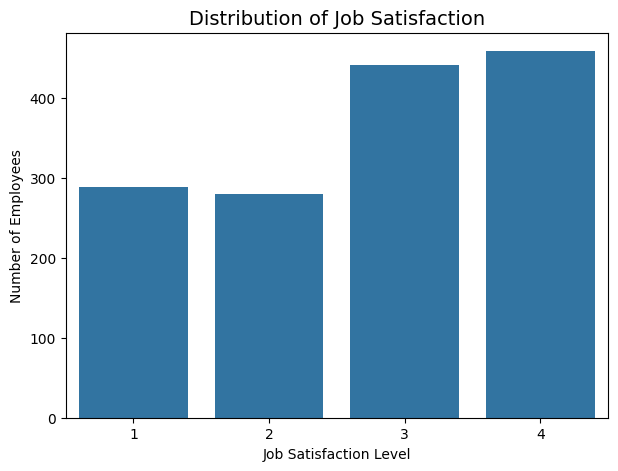

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    order=sorted(df["JobSatisfaction"].unique())
)

plt.title("Distribution of Job Satisfaction", fontsize=14)
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

plt.show()

### Observation

- Employees are distributed across all four satisfaction levels.
- Most employees report moderate to high job satisfaction.

### Business Insight

Job satisfaction levels vary across employees.

## Business Question
How is work-life balance distributed among employees?

In [19]:
df["WorkLifeBalance"].value_counts().sort_index()

WorkLifeBalance
1     80
2    344
3    893
4    153
Name: count, dtype: int64

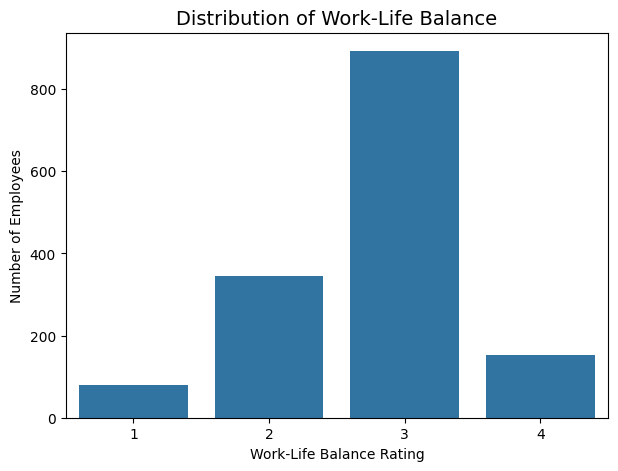

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    order=sorted(df["WorkLifeBalance"].unique())
)

plt.title("Distribution of Work-Life Balance", fontsize=14)
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Number of Employees")

plt.show()

### Observation

- Most employees report average to good work-life balance.
- Very few employees fall into the lowest work-life balance category.

### Business Insight

The workforce generally reports satisfactory work-life balance.

## Bivariate Analysis

## Business Qestion
Does working overtime increase employee attrition?

In [21]:
pd.crosstab(df["OverTime"], df["Attrition"])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [22]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


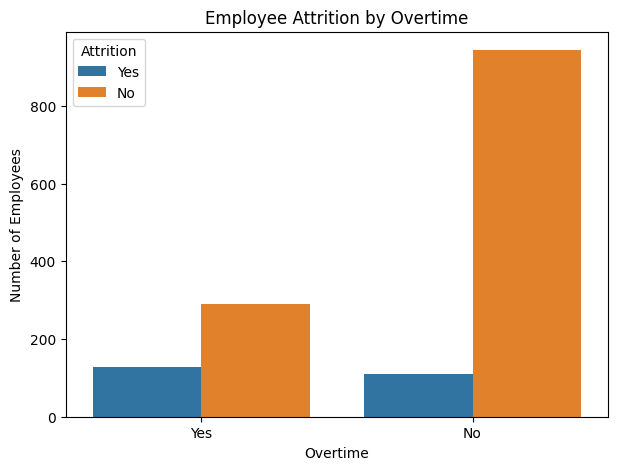

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Employee Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition")

plt.show()

### Observation

- Employees who work overtime show a noticeably higher number of attrition cases.
- Employees who do not work overtime are more likely to remain with the organization.

### Business Insight

Overtime appears to be strongly associated with employee attrition. Employees who frequently work overtime may experience increased workload and stress, making overtime a potential contributor to employee turnover. This suggests that workload management and overtime policies should be reviewed to improve employee retention.

### Recommendation

Review overtime policies and workload distribution to reduce employee burnout and improve employee retention.

## Business Question
Which department has the highest employee attrition rate?

In [25]:
pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)
plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition")

plt.show()

### Observation

- Research & Development has the highest number of employees.
- The Sales department recorded the second-highest number of employees.
- Human Resources has the smallest workforce.
- The number of employees who left varies across the three departments.

### Business Insight

Although Research & Development has the highest number of employees leaving, this may be influenced by its larger workforce.

### Recommendation

HR should prioritize retention efforts in departments with the highest attrition rates by conducting employee feedback sessions, reviewing workloads, and implementing department-specific engagement programs.

## Business Question 
Which job roles have the highest employee attrition?

In [29]:
pd.crosstab(df["JobRole"], df["Attrition"])

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [30]:
pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


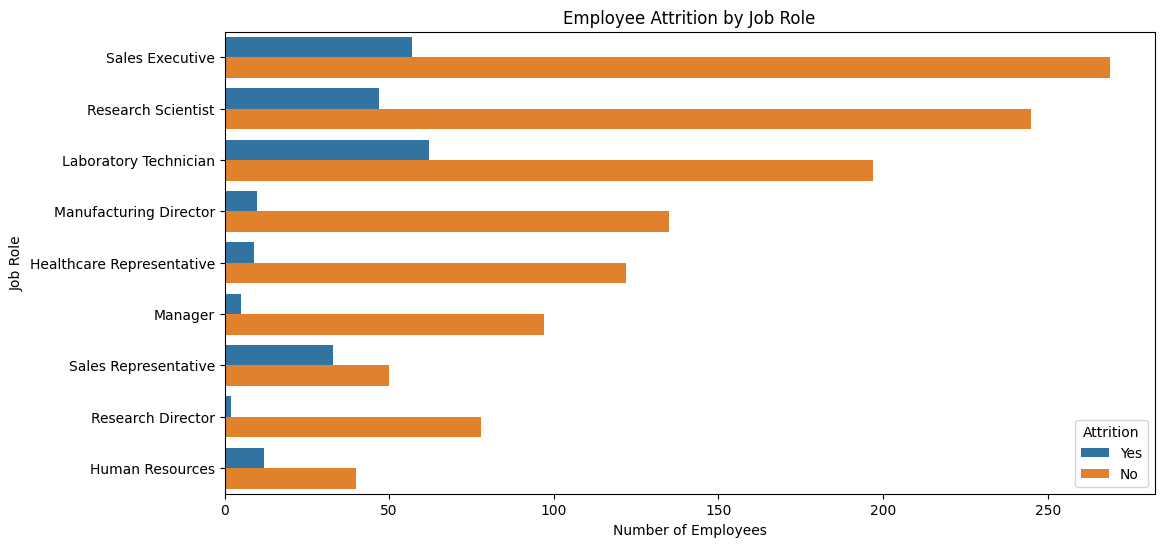

In [31]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition",
    order=df["JobRole"].value_counts().index
)
plt.title("Employee Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.legend(title="Attrition")
plt.show()

### Observation

- Sales Representatives have the highest attrition rate at **39.76%**.
- Laboratory Technicians and Human Resources employees also show relatively high attrition rates of **23.94%** and **23.08%**, respectively.
- Research Directors and Managers have the lowest attrition rates.

### Business Insight

Sales Representatives experience substantially higher employee turnover than other job roles. This suggests that employees in this role may face challenges related to workload, compensation, career progression, or job expectations.

### Recommendation

HR should prioritize retention strategies for Sales Representatives by reviewing compensation structures, career development opportunities, workload distribution, and employee engagement initiatives.

## Business Question
Does Monthly Income influence employee attrition?

In [32]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


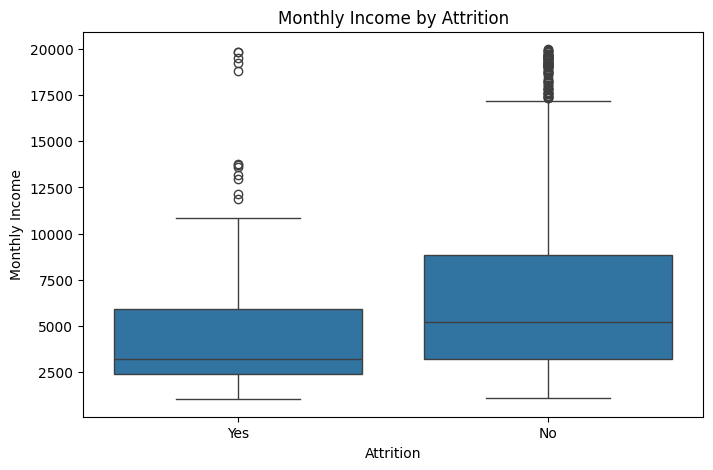

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

### Observation

- Employees who left the organization have a lower median monthly income compared to employees who stayed.
- Employees who remained with the company generally have a higher salary distribution.
- Several high-income employees are observed among employees who stayed with the organization.

### Business Insight

Monthly income appears to be associated with employee attrition. Employees with lower salaries are more likely to leave the organization, suggesting that compensation may be an important factor influencing employee retention.

### Recommendation

The organization should periodically review salary structures, particularly for lower-income employees, to ensure competitive compensation and improve employee retention.

## Business Question

Does employee age influence attrition?

In [34]:
df.groupby("Attrition")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


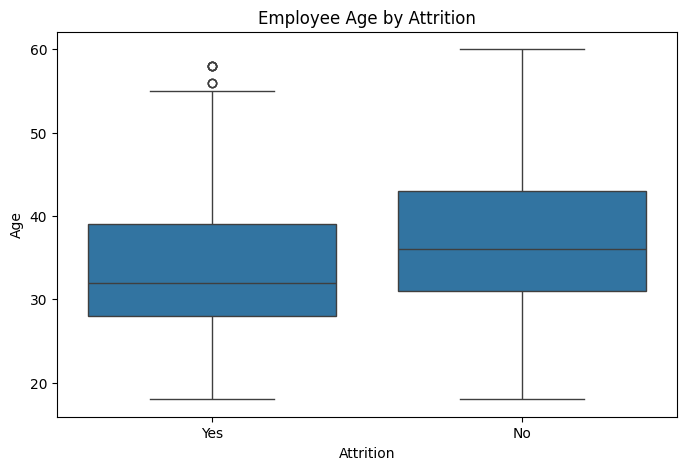

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Employee Age by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

### Observation

- Employees who left the organization have a lower median age than employees who remained.
- Employees who stayed generally belong to an older age group.
- Younger employees show greater representation among employees who left the company.

### Business Insight

Younger employees appear to have a higher tendency to leave the organization. This may indicate that early-career employees are more likely to explore better career opportunities, higher salaries, or faster professional growth.

### Recommendation

The organization should strengthen career development programs, mentorship initiatives, and employee engagement strategies for early-career employees to improve retention.

## Business Question

Does job satisfaction influence employee attrition?

In [40]:
attrition_rate = (
    pd.crosstab(
        df["JobSatisfaction"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

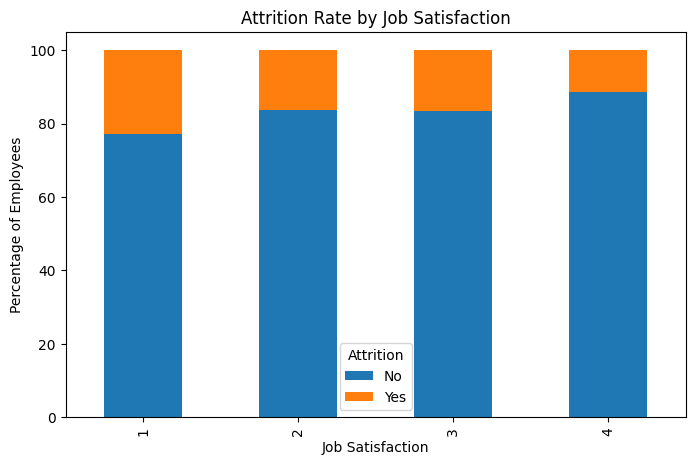

In [41]:
attrition_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Percentage of Employees")
plt.legend(title="Attrition")

plt.show()

### Observation

- Employees with lower job satisfaction levels recorded higher attrition rates.
- As job satisfaction increases, the number of employees leaving the organization decreases.

### Observation

- Employees with lower job satisfaction levels recorded higher attrition rates.
- As job satisfaction increases, the number of employees leaving the organization decreases.

### Business Insight

Job satisfaction appears to have a significant influence on employee attrition. Employees who are less satisfied with their jobs are more likely to leave the organization, indicating that improving employee satisfaction may help reduce turnover.

### Recommendation

The organization should regularly measure employee satisfaction through surveys and feedback sessions while implementing initiatives that improve career growth, recognition, and workplace engagement.

## Business Question

Does work-life balance influence employee attrition?

In [42]:
attrition_rate = (
    pd.crosstab(
        df["WorkLifeBalance"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

attrition_rate

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


<Figure size 800x500 with 0 Axes>

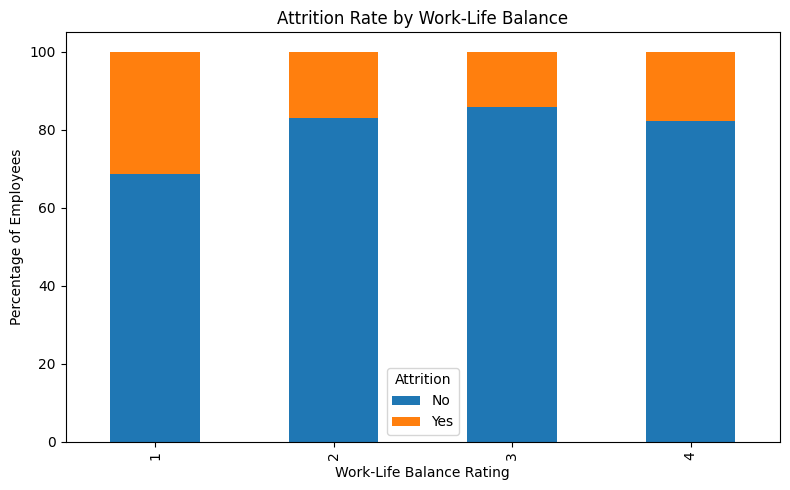

In [43]:
plt.figure(figsize=(8,5))

attrition_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Percentage of Employees")

plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

### Observation

- Employees with lower work-life balance ratings recorded higher attrition rates.
- Employees reporting better work-life balance showed lower employee turnover.

### Business Insight

Work-life balance appears to play an important role in employee retention. Employees who perceive a healthier balance between work and personal life are less likely to leave the organization.

### Recommendation

The organization should strengthen flexible work policies, workload management, and employee well-being initiatives to improve work-life balance and reduce employee turnover.

## Business Question

Does business travel influence employee attrition?

In [44]:
attrition_rate = (
    pd.crosstab(
        df["BusinessTravel"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

attrition_rate

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


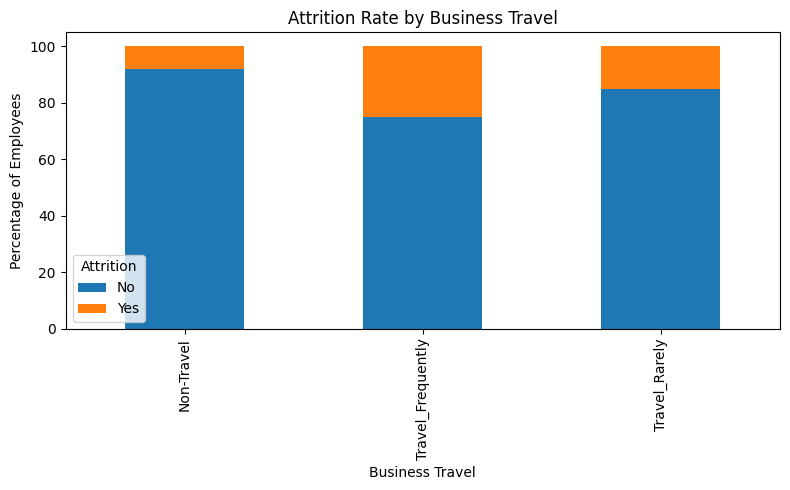

In [45]:
attrition_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Percentage of Employees")

plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

### Observation

- Employees who travel frequently recorded the highest attrition rate.
- Employees who travel rarely showed a comparatively lower attrition rate.
- Non-travel employees recorded the lowest employee attrition.

### Business Insight

Frequent business travel appears to increase employee turnover, possibly due to travel-related stress, fatigue, and reduced work-life balance.

### Recommendation

The organization should evaluate travel requirements and provide additional support, flexible scheduling, or hybrid alternatives for employees who travel frequently.

# Multivariate Analysis

## Business Question

Which numerical variables are most strongly related to each other?

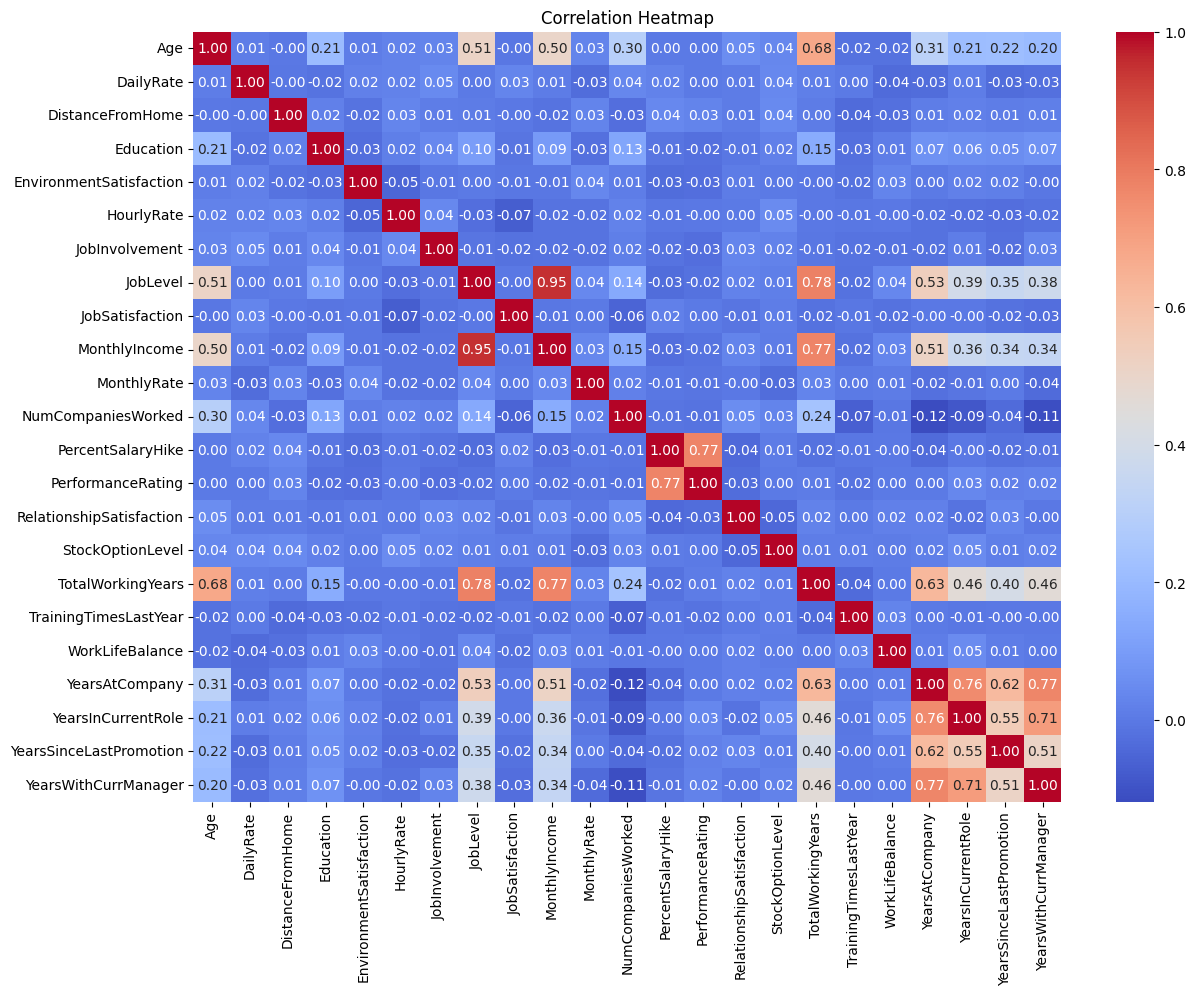

In [46]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The correlation heatmap shows that most numerical variables have weak correlations with one another.
- Strong positive correlations are observed between Job Level and Monthly Income (0.95), Job Level and Total Working Years (0.78), Years at Company and Years with Current Manager (0.77), Years at Company and Years in Current Role (0.76), and Age and Total Working Years (0.68).
- These relationships indicate that employees with greater experience tend to have higher job levels, higher salaries, and longer tenures within the organization.

### Business Insight

The strong correlations among experience-related variables indicate a natural progression in employees' careers, where increased experience is associated with higher job levels and better compensation. Since most other variables show weak correlations, employee attrition is likely influenced by a combination of factors rather than a single numerical variable.

# Key Findings

- Employees who work overtime have a significantly higher attrition rate than employees who do not work overtime.
- Sales Representatives experience the highest employee attrition rate among all job roles.
- Employees with lower monthly incomes are more likely to leave the organization.
- Younger employees tend to have higher attrition compared to older employees.
- Lower job satisfaction and poor work-life balance are associated with increased employee turnover.
- Employees who travel frequently exhibit higher attrition rates than employees who travel rarely or do not travel.
- Experience-related variables such as Job Level, Monthly Income, and Total Working Years show strong positive correlations.

# Conclusion

The exploratory data analysis identified several factors associated with employee attrition, including overtime, job role, monthly income, age, job satisfaction, work-life balance, and business travel. Employees working overtime, earning lower salaries, and reporting lower job satisfaction were found to be more likely to leave the organization. The correlation analysis also revealed strong relationships among experience-related variables such as Job Level, Monthly Income, and Total Working.